#**Classificação: Resolvendo problemas multiclasse**

##**Aula 1 - Conhecendo os dados**

###**Carregando os dados**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/classificacao_multiclasse/main/Dados/dados_estudantes.csv')

In [3]:
df.head()

,Estado civil,Migração,Sexo,Idade na matrícula,Estrangeiro,Necessidades educacionais especiais,Devedor,Taxas de matrícula em dia,Bolsista,Taxa de desemprego,...,disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações),Target
0,Solteiro,Sim,Masculino,20,Não,Não,Não,Sim,Não,10.8,...,0,0.000000,0,0,0,0,0,0.000000,0,Desistente
1,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,13.9,...,6,14.000000,0,0,6,6,6,13.666667,0,Graduado
2,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,10.8,...,0,0.000000,0,0,6,0,0,0.000000,0,Desistente
3,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Não,9.4,...,6,13.428571,0,0,6,10,5,12.400000,0,Graduado
4,Casado,Não,Feminino,45,Não,Não,Não,Sim,Não,13.9,...,5,12.333333,0,0,6,6,6,13.000000,0,Graduado


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Estado civil                              4424 non-null   str    
 1   Migração                                  4424 non-null   str    
 2   Sexo                                      4424 non-null   str    
 3   Idade na matrícula                        4424 non-null   int64  
 4   Estrangeiro                               4424 non-null   str    
 5   Necessidades educacionais especiais       4424 non-null   str    
 6   Devedor                                   4424 non-null   str    
 7   Taxas de matrícula em dia                 4424 non-null   str    
 8   Bolsista                                  4424 non-null   str    
 9   Taxa de desemprego                        4424 non-null   float64
 10  Taxa de inflação                          4424 

###**Entendendo os dados**

In [5]:
df['Target'].unique()

<StringArray>
['Desistente', 'Graduado', 'Matriculado']
Length: 3, dtype: str

In [6]:
df['Estado civil'].value_counts(normalize=True)*100

Estado civil
Solteiro               88.584991
Casado                  8.566908
Divorciado              2.056962
União Estável           0.565099
Legalmente Separado     0.135624
Viúvo                   0.090416
Name: proportion, dtype: float64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

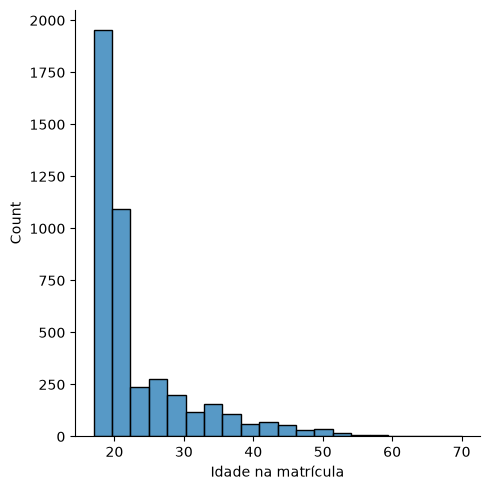

In [8]:
sns.displot(df['Idade na matrícula'], bins=20)
plt.show()

In [9]:
color_dict = {'Desistente': '#e34c42', 'Graduado': '#4dc471', 'Matriculado': '#3b71db'}
sns.set_palette(list(color_dict.values()))

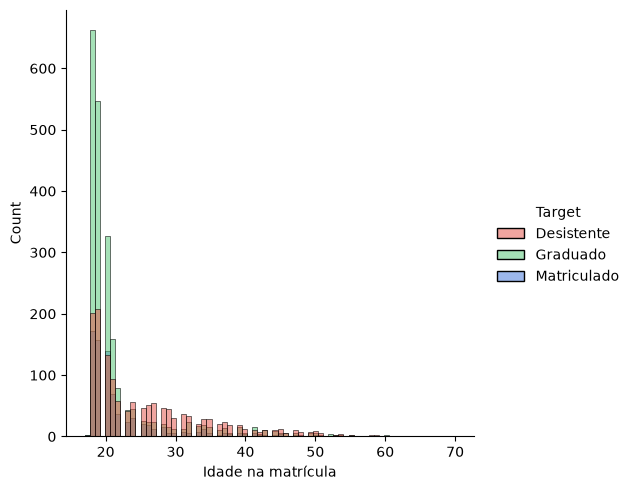

In [10]:
sns.displot(data=df, x='Idade na matrícula', hue='Target')

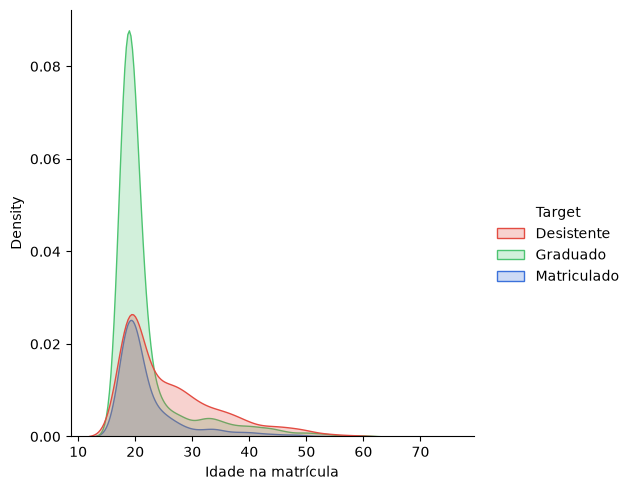

In [11]:
sns.displot(data=df, x='Idade na matrícula', hue='Target',kind='kde',fill=True)
plt.show()

In [12]:
df['Estrangeiro'].value_counts(normalize=True)*100

Estrangeiro
Não    97.513562
Sim     2.486438
Name: proportion, dtype: float64

In [13]:
df['Sexo'].value_counts(normalize=True)*100

Sexo
Feminino     64.82821
Masculino    35.17179
Name: proportion, dtype: float64

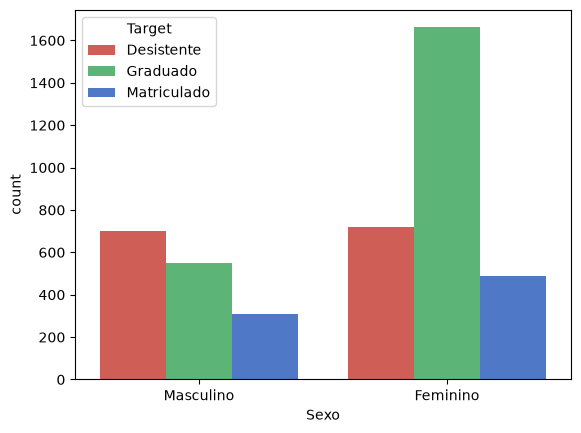

In [14]:
sns.countplot(x='Sexo', hue='Target', data=df)
plt.show()

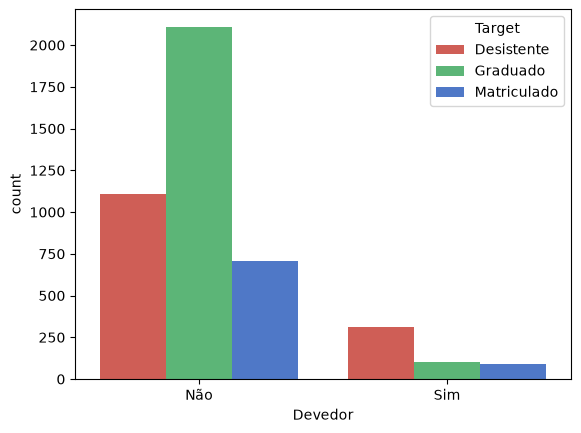

In [15]:
sns.countplot(x= 'Devedor', hue='Target', data=df)
plt.show()

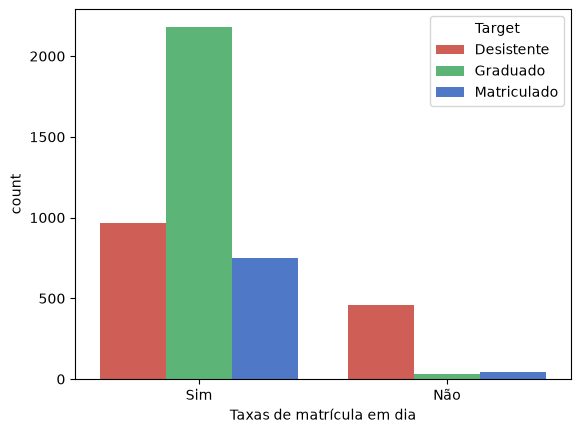

In [16]:
sns.countplot(x= 'Taxas de matrícula em dia', hue='Target', data=df)
plt.show()

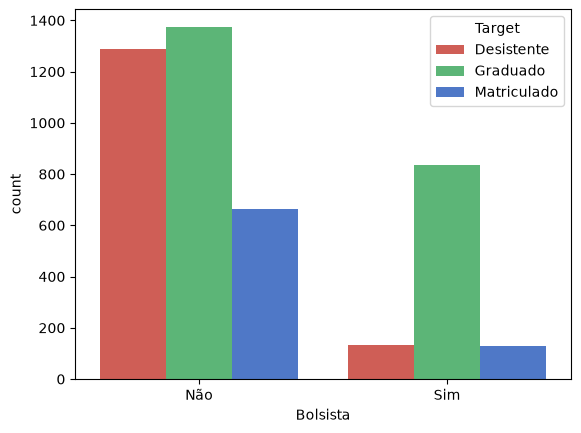

In [17]:
sns.countplot(x= 'Bolsista', hue='Target', data=df)
plt.show()

In [18]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook_connected"

In [19]:
contagem = df.groupby(['Curso', 'Target']).size().reset_index(name='Contagem')
contagem['Porcentagem'] = contagem.groupby('Curso')['Contagem'].transform(lambda x: (x / x.sum()) * 100)
fig = px.bar(contagem, y='Curso', x='Porcentagem', color='Target', orientation='h',color_discrete_map = {'Desistente': '#e34c42', 'Graduado': '#4dc471', 'Matriculado': '#3b71db'})

fig.show()

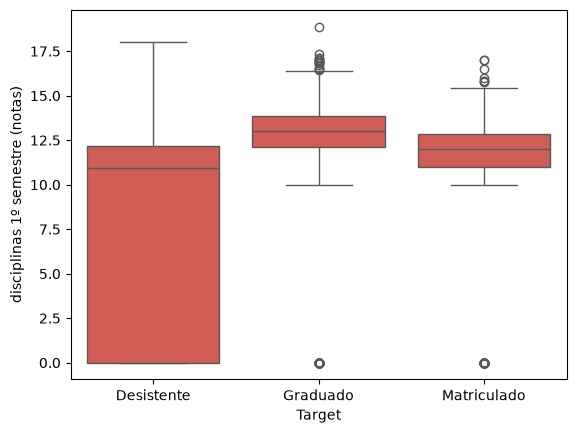

In [20]:
sns.boxplot(x='Target', y='disciplinas 1º semestre (notas)', data=df)
plt.show()

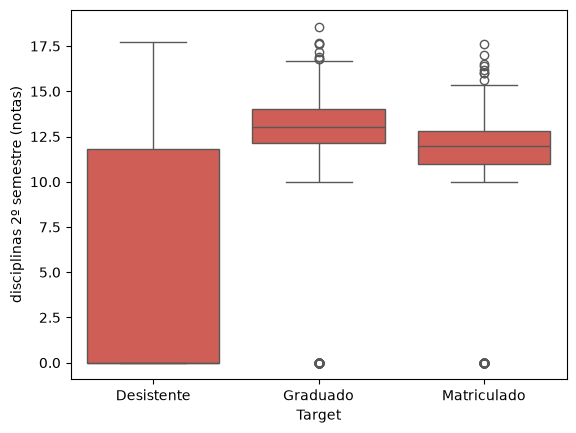

In [21]:
sns.boxplot(x='Target', y='disciplinas 2º semestre (notas)', data=df)
plt.show()

In [22]:
df['Target'].value_counts(normalize=True)*100

Target
Graduado       49.932188
Desistente     32.120253
Matriculado    17.947559
Name: proportion, dtype: float64

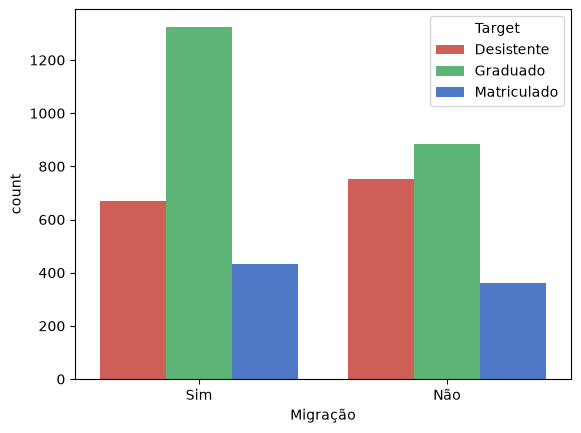

In [23]:
sns.countplot(x='Migração', hue='Target', data=df)
plt.show()

In [24]:
df['Necessidades educacionais especiais'].value_counts(normalize=True)*100

Necessidades educacionais especiais
Não    98.847197
Sim     1.152803
Name: proportion, dtype: float64

In [25]:
df.groupby('Target')['Necessidades educacionais especiais'].value_counts(normalize=True)*100

Target       Necessidades educacionais especiais
Desistente   Não                                    98.803659
             Sim                                     1.196341
Graduado     Não                                    98.958805
             Sim                                     1.041195
Matriculado  Não                                    98.614610
             Sim                                     1.385390
Name: proportion, dtype: float64

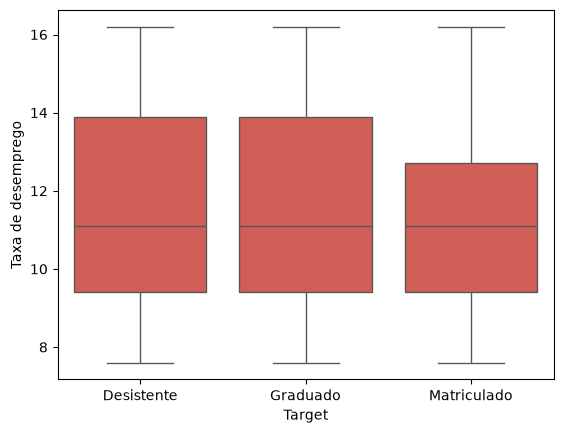

In [26]:
sns.boxplot(x='Target', y='Taxa de desemprego', data=df)
plt.show()

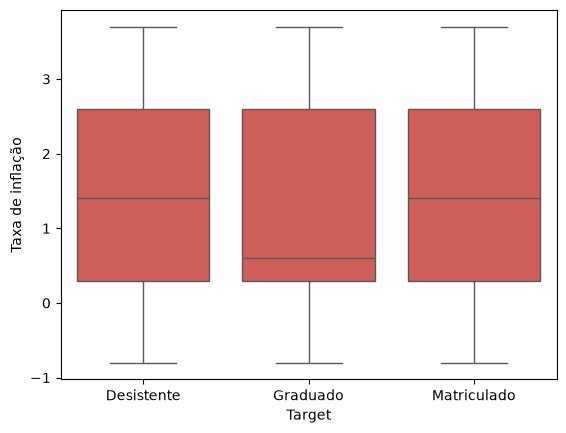

In [27]:
sns.boxplot(x='Target', y='Taxa de inflação', data=df)
plt.show()

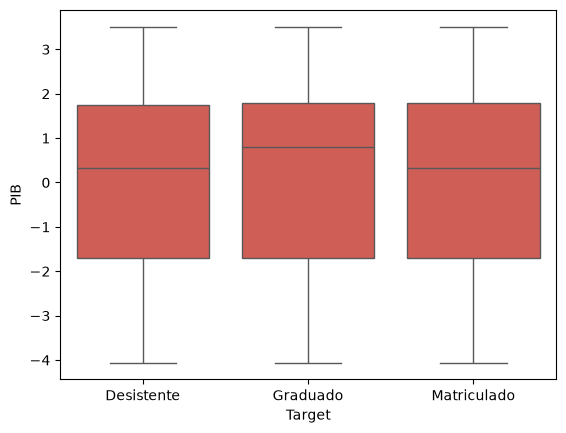

In [28]:
sns.boxplot(x='Target', y='PIB', data=df)
plt.show()

In [29]:
df['Qualificação prévia'].value_counts(normalize=True)*100

Qualificação prévia
Educação secundária                                         84.018987
Curso de especialização tecnológica                          4.950271
Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente     3.661844
Educação superior - licenciatura                             2.848101
Outro - 11º ano de escolaridade                              1.017179
Educação superior - licenciatura (1º ciclo)                  0.904159
Curso técnico superior profissional                          0.813743
Educação superior - bacharelado                              0.519892
Frequência de educação superior                              0.361664
12º ano de escolaridade - não concluído                      0.248644
Educação superior - mestrado                                 0.180832
Educação básica 2º ciclo (6º/7º/8º ano) ou equivalente       0.158228
Educação superior - mestrado (2º ciclo)                      0.135624
11º ano de escolaridade - não concluído                      0.090416


In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
colunas_categoricas = ['Migração', 'Sexo','Estrangeiro', 'Necessidades educacionais especiais', 'Devedor',

                     'Taxas de matrícula em dia', 'Bolsista', 'Período','Estado civil', 'Curso', 'Qualificação prévia']

In [32]:
encoder = OneHotEncoder(drop='if_binary')

In [33]:
df_categorico = df[colunas_categoricas]

In [34]:
df_encoded = pd.DataFrame(encoder.fit_transform(df_categorico).toarray(),
                          columns=encoder.get_feature_names_out(colunas_categoricas))

In [35]:
df_final = pd.concat([df.drop(colunas_categoricas, axis=1), df_encoded], axis=1)

In [36]:
df_final

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),...,Qualificação prévia_Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente,Qualificação prévia_Educação secundária,Qualificação prévia_Educação superior - bacharelado,Qualificação prévia_Educação superior - doutorado,Qualificação prévia_Educação superior - licenciatura,Qualificação prévia_Educação superior - licenciatura (1º ciclo),Qualificação prévia_Educação superior - mestrado,Qualificação prévia_Educação superior - mestrado (2º ciclo),Qualificação prévia_Frequência de educação superior,Qualificação prévia_Outro - 11º ano de escolaridade
0,20,10.8,1.4,1.74,0,0,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,19,13.9,-0.3,0.79,0,6,6,6,14.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19,10.8,1.4,1.74,0,6,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20,9.4,-0.8,-3.12,0,6,8,6,13.428571,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,45,13.9,-0.3,0.79,0,6,9,5,12.333333,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,19,15.5,2.8,-4.06,0,6,7,5,13.600000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4420,18,11.1,0.6,2.02,0,6,6,6,12.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4421,30,13.9,-0.3,0.79,0,7,8,7,14.912500,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4422,20,9.4,-0.8,-3.12,0,5,5,5,13.800000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


para o modelo que vamos treinar que será o RandomForest que é do tipo árvore não preciso me preocupar com as variáveis que são numéricas mas não necessariamente binárias, se fosse algum outro tipo de modelo mais linear isso poderia causar um desbalanceamento do modelo

In [37]:
X = df_final.drop('Target', axis=1)
y = df_final['Target']

divisão entre treino e validação e teste também que é onde voce testa o modelo

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X, X_teste, y, y_teste = train_test_split(X, y, test_size=0.15, stratify=y, random_state=0)
X_treino, X_val, y_treino, y_val = train_test_split(X, y, stratify=y, random_state=0)

a partir daqui os modelos estão separados para serem utilizados

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
modelo_rf = RandomForestClassifier(random_state=0, )
modelo_rf.fit(X_treino, y_treino)
y_pred = modelo_rf.predict(X_val)
print(f'Acurácia de treino: {modelo_rf.score(X_treino, y_treino)}')
print(f'Acurácia de validação: {modelo_rf.score(X_val, y_val)}')

Acurácia de treino: 0.9975177304964539
Acurácia de validação: 0.7680851063829788


In [42]:
modelo_rf = RandomForestClassifier(random_state=0, max_depth=10)
modelo_rf.fit(X_treino, y_treino)
y_pred = modelo_rf.predict(X_val)
print(f'Acurácia de treino: {modelo_rf.score(X_treino, y_treino)}')
print(f'Acurácia de validação: {modelo_rf.score(X_val, y_val)}')

Acurácia de treino: 0.898936170212766
Acurácia de validação: 0.7734042553191489


In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [44]:
matriz_confusao = confusion_matrix(y_val, y_pred)

In [45]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)

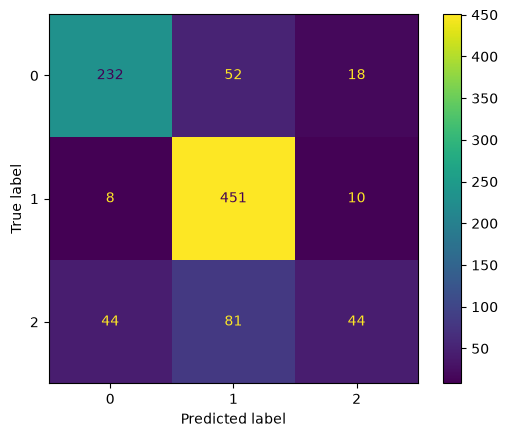

In [46]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualizacao.plot();

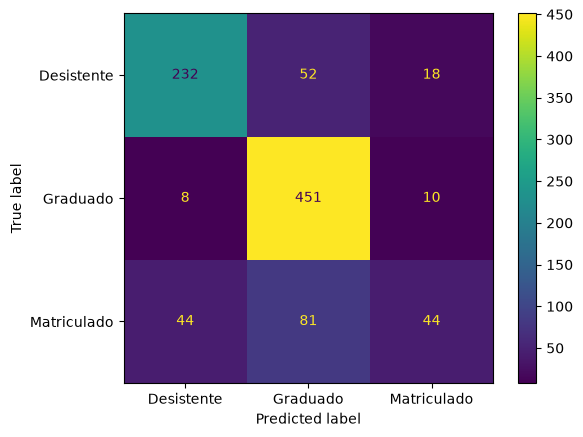

In [47]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=modelo_rf.classes_)
visualizacao.plot();

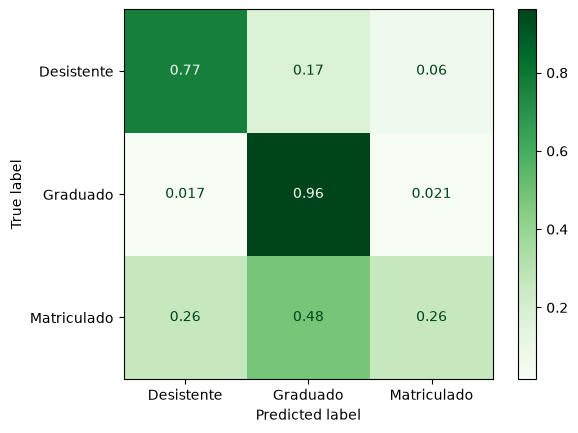

In [48]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Greens')

In [49]:
from sklearn.metrics import classification_report

In [50]:
report = classification_report(y_val, y_pred)
print('Relatório de Classificação:\n', report)

Relatório de Classificação:
               precision    recall  f1-score   support

  Desistente       0.82      0.77      0.79       302
    Graduado       0.77      0.96      0.86       469
 Matriculado       0.61      0.26      0.37       169

    accuracy                           0.77       940
   macro avg       0.73      0.66      0.67       940
weighted avg       0.76      0.77      0.75       940



In [51]:
y_treino.value_counts()

Target
Graduado       1408
Desistente      906
Matriculado     506
Name: count, dtype: int64

In [54]:
from imblearn.over_sampling import SMOTE

In [55]:
oversample = SMOTE(random_state=0)
x_balanceado, y_balanceado = oversample.fit_resample(X_treino, y_treino)

In [56]:
y_balanceado.value_counts()

Target
Desistente     1408
Graduado       1408
Matriculado    1408
Name: count, dtype: int64

In [57]:
modelo = RandomForestClassifier(random_state=0, max_depth=10)
modelo.fit(x_balanceado, y_balanceado)
y_pred = modelo.predict(X_val)

              precision    recall  f1-score   support

  Desistente       0.85      0.72      0.78       302
    Graduado       0.81      0.88      0.84       469
 Matriculado       0.48      0.50      0.49       169

    accuracy                           0.76       940
   macro avg       0.71      0.70      0.70       940
weighted avg       0.76      0.76      0.76       940



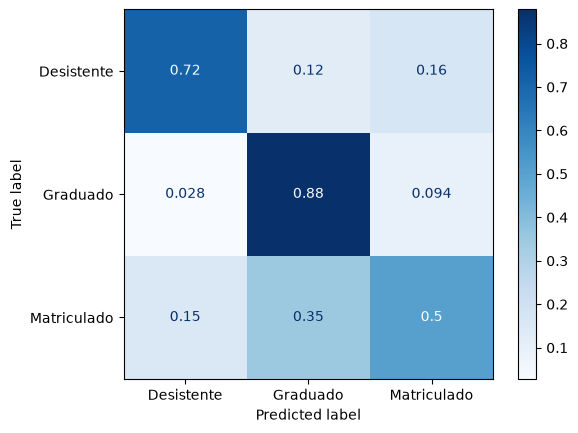

In [58]:
print(classification_report(y_val, y_pred))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues')

In [59]:
from imblearn.pipeline import Pipeline as imbpipeline



In [60]:
modelo = RandomForestClassifier(max_depth = 10)
pipeline = imbpipeline([('oversample', SMOTE()), ('floresta', modelo)])

In [61]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [62]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring='recall_weighted')
cv_resultados['test_score']

array([0.76329787, 0.73138298, 0.74867021, 0.76462766, 0.74468085])

In [63]:
media = cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()
print(f'intervalo de confiança: [{media - 2 * desvio_padrao}, {min(media + 2 * desvio_padrao, 1.0)}]')

intervalo de confiança: [0.7257764334505955, 0.7752873963366386]


              precision    recall  f1-score   support

  Desistente       0.87      0.74      0.80       213
    Graduado       0.82      0.85      0.84       332
 Matriculado       0.47      0.55      0.51       119

    accuracy                           0.76       664
   macro avg       0.72      0.71      0.71       664
weighted avg       0.77      0.76      0.77       664



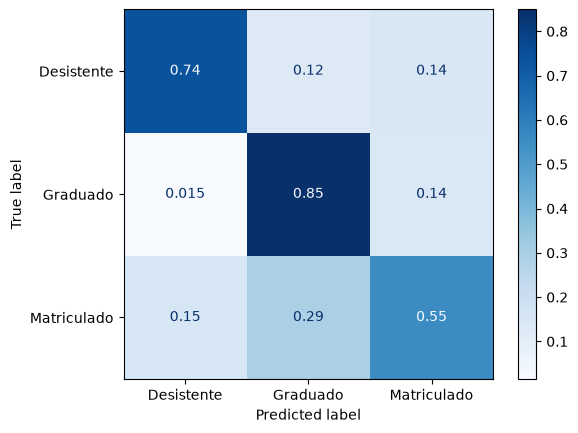

In [64]:
oversample = SMOTE(random_state=0)
X_balanceado, y_balanceado = oversample.fit_resample(X, y)
modelo = RandomForestClassifier(random_state=0, max_depth=10)
modelo.fit(X_balanceado, y_balanceado)
y_pred = modelo.predict(X_teste)

print(classification_report(y_teste, y_pred))
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred, normalize='true', cmap='Blues');